In [ ]:
# /// script
# requires-python = ">=3.13"
# dependencies = [
#     "careamics[examples]>=0.3.0, <0.4.0",
# ]
# [tool.uv.sources]
# careamics = {git = "https://github.com/CAREamics/careamics", branch = "main"}
# ///

# Noise2Void in CAREamics

Noise in microscopy images is often a limiting factor for downstream analysis. A popular
algorithm for deep-learning denoising is Noise2Void. 

What is Noise2Void good for?

- It is self-supervised, no need to have ground truth images for training
- It trains fast!
- Most microscopy images contain noise that is uncorrelated spatially.

What are its limitations?

- Some microscopy methods have spatial correlations in the noise, if these are strong enough
then Noise2Void will make the correlation appear strongly in the resulting image (see structN2V, HDN or COSDD for
a potential solution)
- In the presence of salt and pepper noise, or hot pixels, Noise2Void can produce checkerboard
artefacts (see N2V2 for a solution)

The way to run Noise2Void is through the [CAREamics library](https://careamics.github.io/latest/).

In [173]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import data
import numpy as np
from scipy.ndimage import convolve
from torch import tensor
from microssim import MicroSSIM

from careamics import CAREamist
from careamics.config import create_n2v_config, create_structn2v_config
from careamics.plotting import plot_loss
from careamics.metrics.metrics import scale_invariant_psnr

from careamics.utils import autocorrelation, get_device
from careamics.config.algorithms.n2v_manipulation import N2VManipulateConfig
from careamics.lightning.modules.n2v_module import N2VManipulate


In [139]:
# used at the end of the notebook
all_preds = {}
all_noisy = {} 

Image shape: (60, 256, 256)


Text(0.5, 1.0, 'Crop')

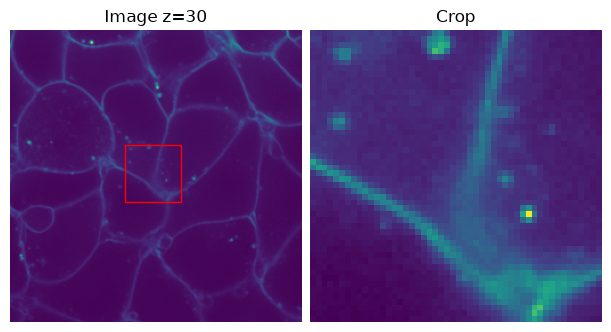

In [ ]:
# Download example data
img = data.cells3d()[:, 0]
print(f"Image shape: {img.shape}")

# Define some re-usable variables
z_mid = 30
crop = (slice(100, 150),) * 2

# Plot
fig, axes = plt.subplots(1, 2, figsize=(6, 6), constrained_layout=True)

rect = patches.Rectangle((100, 100), 50, 50, linewidth=1, edgecolor='r', facecolor='none')

axes[0].imshow(img[z_mid])
axes[0].add_patch(rect)
axes[0].axis("Off")
axes[0].set_title("Image z=30")

axes[1].imshow(img[z_mid, *crop])
axes[1].axis("Off")
axes[1].set_title("Crop")

<div style="
  background: #fff8db;
  border-left: 6px solid #e2b200;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #8a6a00;
">
  <strong style="color: #8a6a00;">Important</strong><br>
  
  We are going to use this 3D image as example throughout this notebook. In particular,
  we are going to add noise to it. Obviously, it does contain a bit noise already but
  this should not be an issue for today's purpose.
</div>

## 1 - Primer into noise

The leading noise components in microscopy are typically shot noise and read-out noise.
Shot noise arise from the stochasticity of the number of photons that reach the detector
and, due to the discrete nature of light, is Poisson distributed. Read-out noise is
added by the detector and often considered Gaussian distributed and additive.

Therefore, a noisy pixel can be considered as the result of the following equation:

$$y = \mathcal{P}(y_{true}) + \mathcal{N}(0, \sigma)$$

where the number of photons reaching the camera is a draw from the Poisson distribution
$\mathcal{P}$ parameterized by the true intensity $y_{true}$, with read-out noise
added and parameterized by $\sigma$.

<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>
  Some properties of the Poisson distribution are important to keep in mind:

  - It cannot be negative
  - Its standard deviation is equal to the square root of its mean: $\sigma=\sqrt(\mu)$
</div>

<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>
  This is a simple picture. Here, both shot noise and read-out noise are independent from
  pixel to pixel. It is an important assumption for Noise2Void.

  We will also explore what happens when correlations are present in the noise. Note that
  correlations are not rare in the noise of microscopy images. For instance point-scanning
  microscopy methods can introduce correlations in the noise.
</div>

Let's add some noise to our example image.

In [ ]:
def get_gaussian_noise(img: np.ndarray, c: int) -> tuple[np.ndarray, np.ndarray]:
    """Generate Gaussian additive noise.

    Parameters
    ----------
    img : np.ndarray
        Image to which noise should be added.
    c : int
        Noise strength (au).

    Returns
    -------
    np.ndarray
        Resulting noisy image.
    np.ndarray
        Noise. 
    """
    rng = np.random.default_rng(24)

    noise = rng.normal(0, c, img.shape)
    noisy = np.clip(img+noise, 0, None)

    return noisy, noisy-img

def get_poisson_noise(img: np.ndarray, c: int) -> tuple[np.ndarray, np.ndarray]:
    """Generate Poisson-distributed noise.

    Aka shot noise.

    Parameters
    ----------
    img : np.ndarray
        Image to which noise should be added.
    c : int
        Noise strength (au).

    Returns
    -------
    np.ndarray
        Resulting noisy image.
    np.ndarray
        Noise. 
    """
    rng = np.random.default_rng(24)

    noisy = rng.poisson(img / c) * c

    return noisy, noisy-img

def _add_correlations(noise: np.ndarray, d: int = 3) -> np.ndarray:
    """Add correlations to a noise map.

    Parameters
    ----------
    noise : np.ndarray
        Noise map.
    d : int
        Size of the correlation.

    Returns
    -------
    np.ndarray
        Resulting corelated noise.
    """
    noise_kernel  = np.array([[[1] * d]]) / d # horizontal correlations
    return convolve(noise, noise_kernel)

def get_corr_gaussian_noise(img: np.ndarray, c: int) -> tuple[np.ndarray, np.ndarray]:
    """Generate correlated Gaussian additive noise.

    Parameters
    ----------
    img : np.ndarray
        Image to which noise should be added.
    c : int
        Noise strength (au).

    Returns
    -------
    np.ndarray
        Resulting noisy image.
    np.ndarray
        Noise. 
    """
    rng = np.random.default_rng(24)

    noise = rng.normal(0, c, img.shape)
    corr_noise = _add_correlations(noise)
    noisy = np.clip(img+corr_noise, 0, None)

    return noisy, noisy-img

# noise strength
c_example = int(img.mean())

# generate several noisy images with various noise sources
img_poiss, noise_poiss = get_poisson_noise(img, c_example)
img_gauss, noise_gauss = get_gaussian_noise(img, c_example)
img_corr, noise_corr = get_corr_gaussian_noise(img, c_example)

print(f"Image statistics: mean = {img.mean():.2f}, min = {img.min():.2f}, max = {img.max():.2f}")
print(f"Poisson noise: mean = {img_poiss.mean():.2f}, min = {img_poiss.min():.2f}, max = {img_poiss.max():.2f}")
print(f"Additive Gaussian: mean = {img_gauss.mean():.2f}, min = {img_gauss.min():.2f}, max = {img_gauss.max():.2f}")
print(f"Correlated Gaussian: mean = {img_corr.mean():.2f}, min = {img_corr.min():.2f}, max = {img_corr.max():.2f}")
all_noisy["n2v_poisson"] = img_poiss
all_noisy["n2v_gauss"] = img_gauss
all_noisy["n2v_corr"] = img_corr

Image statistics: mean = 2659.64, min = 0.00, max = 65535.00
Poisson noise: mean = 2226.27, min = 0.00, max = 79004.82
Additive Gaussian: mean = 2983.62, min = 0.00, max = 67484.23
Correlated Gaussian: mean = 2744.26, min = 0.00, max = 66165.88


Our images have similar statistics. Let's have a look at them.

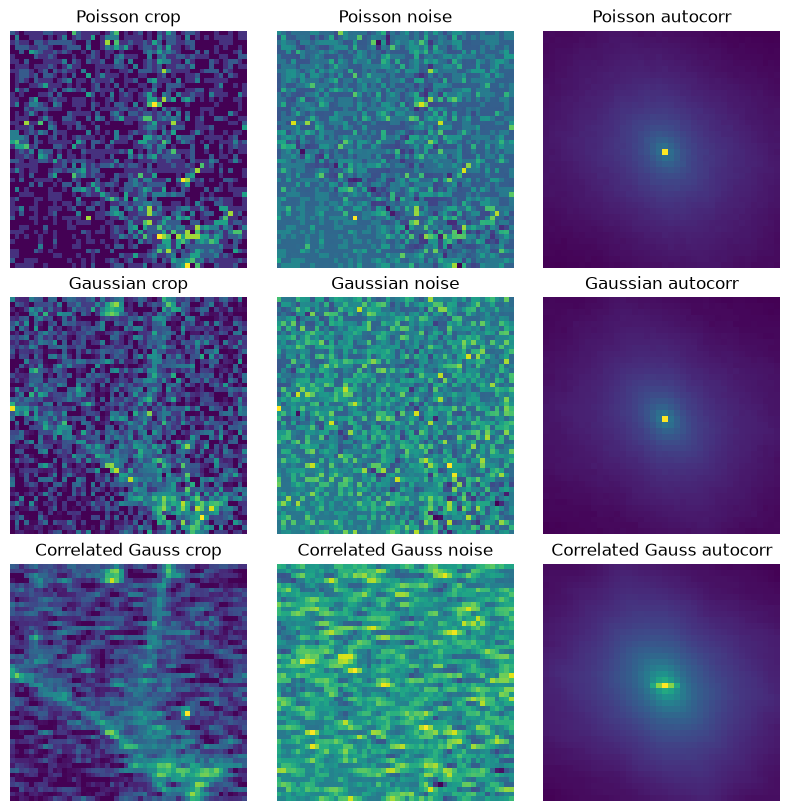

In [204]:
noisy_imgs = [img_poiss, img_gauss, img_corr]
noise_maps = [noise_poiss, noise_gauss, noise_corr]
names = ["Poisson", "Gaussian", "Correlated Gauss"]

fig, axes = plt.subplots(len(noisy_imgs), 3, figsize=(8,8), constrained_layout=True)
for i, (im, noi, name) in enumerate(zip(noisy_imgs, noise_maps, names, strict=True)):
    # compute autocorrelation (in 2D)
    autocorr = autocorrelation(im[z_mid])
    a_mid = autocorr.shape[0] // 2
    a_slices = (slice(a_mid - 20, a_mid + 20),) * 2

    axes[i, 0].imshow(im[z_mid, *crop])
    axes[i, 0].set_title(f"{name} crop")
    axes[i, 0].axis("Off")

    axes[i, 1].imshow(noi[z_mid, *crop])
    axes[i, 1].set_title(f"{name} noise")
    axes[i, 1].axis("Off")

    axes[i, 2].imshow(autocorr[*a_slices])
    axes[i, 2].set_title(f"{name} autocorr")
    axes[i, 2].axis("Off")

<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  How do the properties of the distributions (Poisson, Gaussian) show in this plot?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
      <p>Here, the Poisson noise depends on the value of the pixel (since we applied it to
      an existing image). So the stength of the fluctuations (standard deviation) around the original value
      scales with square root of the original pixel value. Therefore, we expect to see
      the bright structures in the noise.</p>
      <p>The Gaussian noise was added and does not depend on the pixel value. However, because
      Gaussian noise can be negative, we clipped it to 0. So pixel of low intensity may
      have become of value 0. Bright structures should not be visible in the noise.</p>
      <p>Finally, we also introduced correlated noise. It appears in both image, noise and
      autocorrelation as a horizontal line.</p>
  </details> 
</div>

<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  If the amount of shot noise (Poisson distributed) scales with the intensity, why do we get images
  that are less noisy when we crank up the laser or use longer exposure time?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
      There is more "noise", but the signal-to-noise ratio scales with the square root
      of the pixel value. Therefore it increases!
  </details> 
</div>

## 2 - How does Noise2Void works?

Noise2Void has two fundamental hypothesis:

- The signal (biological structures in the image) is continuous
- The noise is independent from pixel to pixel

Since biological structures are continuous, and the noise is typically dominated by shot
noise or read-out noise, these hypothesis hold in most cases.

The idea at the core of Noise2Void is that if we ask a neural network to guess the value
of a pixel, given only the surrounding pixels, then it can only converge towards a noise-free
estimate of the real pixel value. Indeed, the surrounding pixels hold structural information
about the most probable amoung of signal in that pixel, while the noise being independent
means that it is impossible for the model to guess what the original amount of noise was.

In practice, that means that we train a neural network with patches that are missing pixels,
and that we compute the loss on these pixel only. Therefore, the only task the model is given
is to predict pixels values it cannot only infer from its surroundings.

Let's visualize this!

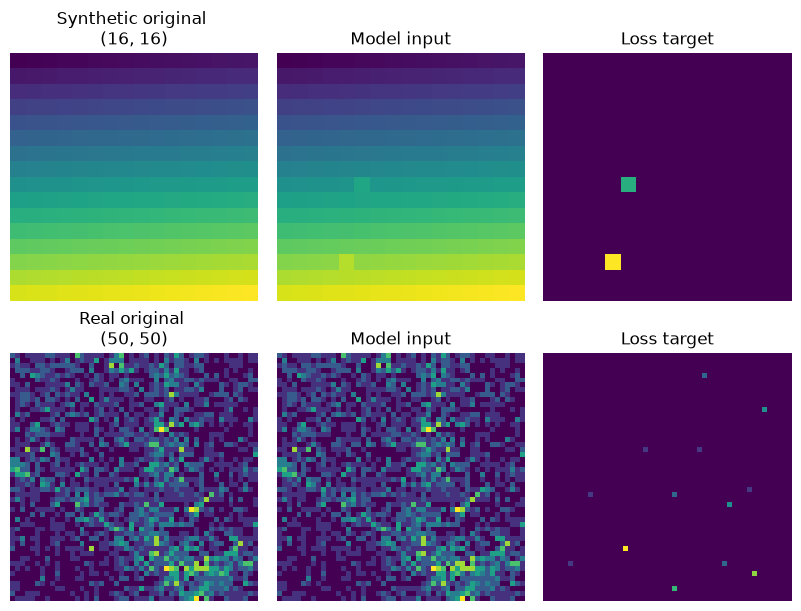

In [87]:
# In CAREamics core, Noise2Void is implemented using the N2VManipulate class
n2v_config = N2VManipulateConfig(
    # changing defaults for the purpose of the exercise
    roi_size=7,
    masked_pixel_percentage=1,
    seed=42
)
n2v_op = N2VManipulate(n2v_config)

# Let's look at what it does with a synthetic and a real example
shape = (16, 16)
synth_img = np.arange(np.prod(shape)).reshape(shape)
real_img = img_poiss[z_mid, *crop]

# Apply N2V manipulate transform
# note:
# we need to abide by CAREamics internal axes BC(Z)YX for the transform, pass tensor
# rather than a numpy array, and ensure that it is on the correct device (GPU vs CPU)
synth_masked, _, synth_mask = n2v_op(
    tensor(synth_img[np.newaxis, np.newaxis], device=get_device())
)
real_masked, _, real_mask = n2v_op(
    tensor(real_img[np.newaxis, np.newaxis], device=get_device())
)

# Let's compare the original images and the manipulated ones
orig_imgs = [synth_img, real_img]
masked_imgs = [synth_masked.cpu().numpy().squeeze(), real_masked.cpu().numpy().squeeze()]
loss_imgs = [
    synth_mask.cpu().numpy().squeeze() * synth_img,
    real_mask.cpu().numpy().squeeze() * real_img
]
names = ["Synthetic", "Real"]

fig, axes = plt.subplots(len(orig_imgs), 3, figsize=(8, 6), constrained_layout=True)
for i, (im, masked, mask, nam) in enumerate(zip(orig_imgs, masked_imgs, loss_imgs, names, strict=True)):

    axes[i, 0].imshow(im)
    axes[i, 0].axis("Off")
    axes[i, 0].set_title(f"{nam} original \n{im.shape}")

    axes[i, 1].imshow(masked)
    axes[i, 1].axis("Off")
    axes[i, 1].set_title("Model input")

    axes[i, 2].imshow(mask)
    axes[i, 2].axis("Off")
    axes[i, 2].set_title("Loss target")


<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>
  Each training step (one batch of input patches), the model takes an input in which
  pixels are masked and produces a whole patch output. The loss (mean squared error) is
  computed between the original masked pixel values and the values the model produced
  for these specific pixels.

</div>

<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  Can you guess how the selected pixel are masked? Are they replaced with 0 values?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
    In Noise2Void, the selected pixel values are replaced by values randomly (uniformly)
    selected from their surrounding ("roi_size" parameter). In N2V2, they are replaced
    by the median value of their surroundings.
      
  </details> 
</div>

<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  If the loss is the mean squared error between original and predicted value, can the
  model reach a perfect state where the loss converges to an infinitesimal value?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
    No, in Noise2Void the loss is no longer indicative of improved training after just a
    few epochs.
      
  </details> 
</div>

## 3 - Running Noise2Void in CAREamics

<img src="https://careamics.github.io/latest/images/banner_careamics_large.png">



Enough theory, let's apply Noise2Void to our syntethic data. We will be using [CAREamics](https://careamics.github.io/), the most up-to-date implementation of Noise2Void.

<div style="
  background: #fff8db;
  border-left: 6px solid #e2b200;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #8a6a00;
">
  <strong style="color: #8a6a00;">Important</strong><br>
  
  You are welcome to try with your own data. Do check the [documentation](https://careamics.github.io/latest/content/guides/current/), in particular regarding [how to confgiure the training](https://careamics.github.io/latest/content/guides/current/configuration/)
  for your application.
</div>

<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>
  CAREamics offers multiple staple algorithms (Noise2Void, N2V2, structN2V, CARE, Noise2Noise)
  and more complex image restoration methods (HDN, MicroSplit). Currently, we only officially
  support the former.

</div>

### Notebook parameters

In order to make these cells re-usable, let's first define on which images we are going
to train Noise2Void. As optional exercises, we are also leaving some parameters that
can later be changed.

In [186]:
# --- Parameters
use_n2v2 = False # see optional exercise at the end of the section
exp_name = "n2v_poisson" # "n2v_gauss", "n2v_poisson", "n2v_corr"

if exp_name == "n2v_poisson":
    input_img = img_poiss
elif exp_name == "n2v_corr":
    input_img = img_corr
else:
    # otherwise default to Gaussian noise image
    exp_name = "n2v_gauss"
    input_img = img_gauss

### Train N2V



In [187]:
# Now we can create a configuration for Noise2Void and train CAREamics
config = create_n2v_config(
    experiment_name=exp_name,
    # If you are loading images from disk, you can choose "tiff", "czi" or "zarr"
    data_type="array",
    # The axes in your data, in the correct order!
    axes="ZYX",
    # Number of patches per step, can be adjusted to fit GPU memory
    batch_size=16,
    # Patch dimensions, must correspond to spatial axes, be large enough to allow the
    # model to understand the structures in the image correctly, and small enough
    # to fit in your GPU memory, can be adjusted/
    patch_size=(8, 64, 64),
    # How long to train, another parameter "num_steps" is available
    num_epochs=60,
    # This is another iteration of Noise2Void, see optional exercises
    use_n2v2=use_n2v2,
)

# create a CAREamist object, responsible for training and prediction
careamist = CAREamist(config)

# train!
careamist.train(train_data=input_img)

No working directory provided. Using current working directory: /Users/joran.deschamps/git/careamics/i2k_workshop/n2v.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1455616962
Computing mean/std statistics: 100%|██████████| 120/120 [00:00<00:00, 4947.47it/s]
Computed mean-std for input: means = [2688.247], stds = [3280.14246896]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ UNet             │  997 K │ train │     0 │
│ 1 │ metrics │ MetricCollection │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 997 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 997 K                                                                                                
Total estimated model params size (MB): 3.991                                                                      
Modules in train mode: 41                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


### Plot loss

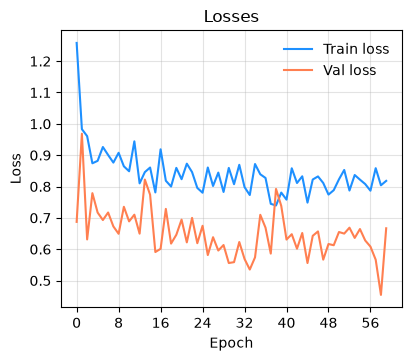

In [188]:
# Plot loss
plot_loss(careamist.get_losses(), plot_metrics=False, plot_learning_rate=False)


<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  Remember the discussion about the loss in Noise2Void, how do you interpret the sharp
  decrease at the beginning of the training?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
    In the first steps, Noise2Void learns structural prior about the image content. Rapidly,
    it converges towards the ball-park of the original pixel values. Later steps and epochs
    show fluctuations around the original (noisy) pixel value.
      
  </details> 
</div>

<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  When should we stop training?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
    There is not answer to that question. It is often good to let the loss plateau and
    fluctuate a bit.

    CAREamics allows you to [save multiple checkpoints](https://careamics.github.io/latest/content/guides/current/configuration/#checkpoint-callback) (= trained models), which you can then load to
    compare perfomances qualitatively.
      
  </details> 
</div>

### Prediction

Let's perform some prediction and compare with the original image.


<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  In deep-learning, we usually learn that the performance of a model should only be
  evaluated on a test set, not on the training images on which we specifically trained the model
  to perform well. Why is it fine with Noise2Void?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
    you can consider that the training data was the masked pixels, leaving many pixels
    Noise2Void is self-supervised and was not biased towards any ground truth. Besides,
    as test set.
</div>

<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>
  
  Noise2Void loads the last checkpoint for prediction. You can choose [which checkpoint](https://careamics.github.io/latest/content/guides/current/careamist_predicting/#choosing-the-checkpoint) to use.

</div>

In [189]:
# Predict
predictions, _ = careamist.predict(pred_data=input_img)
prediction =  predictions[0] # predictions is a list, but we only have one image

# Here we save the predictions with the name of the experiment for the optional
# comparison at the end of the notebook
all_preds[exp_name] = prediction

Creating prediction output directory: '/Users/joran.deschamps/git/careamics/i2k_workshop/n2v'
Restoring states from the checkpoint path at /Users/joran.deschamps/git/careamics/i2k_workshop/n2v/checkpoints/n2v_poisson_4/n2v_poisson_last.ckpt
Loaded model weights from the checkpoint at /Users/joran.deschamps/git/careamics/i2k_workshop/n2v/checkpoints/n2v_poisson_4/n2v_poisson_last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

### Quality control

How to know if the training went well? Here are a few pointers:

<b>Qualitative measures</b>
- Loss did not diverge (rare) and fluctuated around a plateau
- Absence of pixel noise upon visual inspection
- Residuals do not contain structures
- Denoising of a similar image acquired with the same settings looks good as well
- Performance on a downstream task, typically segmentation

<b>Quantitative measures</b>
If you have a ground-truth image (e.g. cranked up laser power or longer exposure time),
or an average of noisy images (from the same exact sample and position):
- Measure PSNR and MicroSSIM metrics between ground-truth and prediction

<b>Additional experiments</b>
- Train multiple models and compare outputs

Since we have a pseudo-ground-truth for the purpose of the exercises (original images),
let's do some qualitative and quantitative control.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

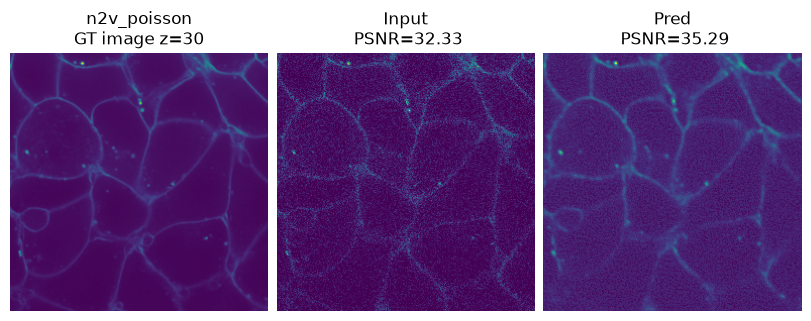

In [190]:
# Check results qualitatively
fig, axes = plt.subplots(1, 3, figsize=(8, 8), constrained_layout=True)

axes[0].imshow(img[z_mid])
axes[0].set_title(f"{exp_name}\nGT image z={z_mid}")
axes[0].axis("off")

# noisy data
noi_psnr = scale_invariant_psnr(img, input_img)

axes[1].imshow(input_img[z_mid])
axes[1].set_title(f"Input\n PSNR={noi_psnr:.2f}")
axes[1].axis("off")

# prediction
pred_psnr = scale_invariant_psnr(img, prediction)

axes[2].imshow(prediction[z_mid])
axes[2].set_title(f"Pred\n PSNR={pred_psnr:.2f}")
axes[2].axis("off")

<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>
  
  Why does the Noise2Void predictions look blurry?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
      Denoising an image is an inverse problem that does not have a single solution. For
      a single image, there is an entire distribution of potential denoised images that
      could, under the noise distribution, give the same resulting noisy image.

      Noise2Void trains using mean squared error, mathematically learning an average of
      all potential solutions to the inverse problem. Therefore, instead of a crisp image
      we get the average of all possible crisp images. Hence the blurriness.

      Note that some algorithms, such as HDN or COSDD, are based on variational-autoencoders
      (VAE) and are made to sample that distribution, returning crisp images. In addition to
      being on paper more performant than Noise2Void, they can return severa samples (crisp images),
      the average prediction (so called MMSE image) and an estimate of the error (std of all predictions).
  </details>
</div>

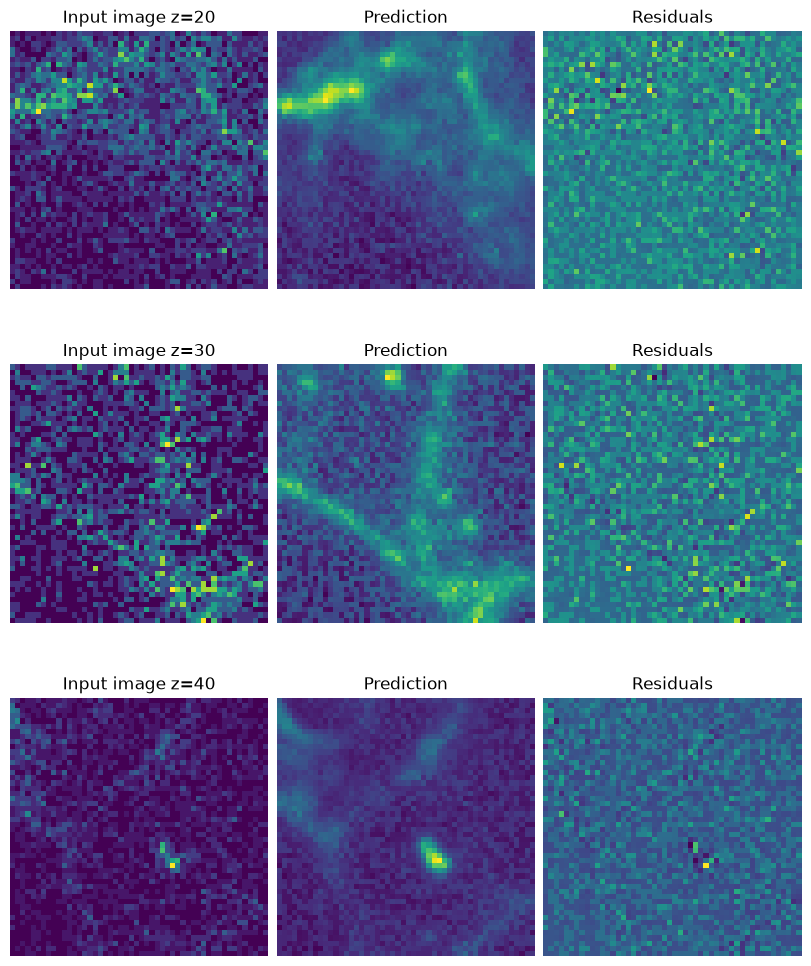

In [191]:
# Check results qualitatively
zs = [20, 30, 40]
fig, axes = plt.subplots(len(zs), 3, figsize=(8, 10), constrained_layout=True)

for i, z in enumerate(zs):
    noisy = input_img[z, *crop]
    pred = predictions[0][z, *crop]
    res = noisy - pred

    axes[i, 0].imshow(noisy)
    axes[i, 0].set_title(f"Input image z={z}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(pred)
    axes[i, 1].set_title("Prediction")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(res)
    axes[i, 2].set_title("Residuals")
    axes[i, 2].axis("off")

## Optional exercises

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise</strong><br>
  Train and predict on the other noisy images (e.g. Poisson, correlated Gaussian).
</div>

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise</strong><br>
  N2V2 is another iteration of Noise2Void. It aims at solving the checkerboard artefacts
  that are sometimes encountered with Noise2Void. The difference with Noise2Void are
  two-fold:

  - Modified network to introduce more blurring
  - Median-value pixel replacement during masking

  Change "use_n2v2" to "True" and test the results. Make sure to redefine the experiment
  name and to not override predictions in "all_preds" (alternatively you can add the prediction
  to "all_preds" under another name).
</div>

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise</strong><br>

  If you ran Noise2Void on the correlated noise, you will see that the pixel values
  remain clearly correlated. You can try to run [structN2V](https://careamics.github.io/latest/content/guides/current/configuration/#structn2v) with "horizontal" mask of span 5. Make sure to redefine the experiment
  name and to not override predictions in "all_preds" (alternatively you can add the prediction
  to "all_preds" under another name).
</div>

## Bonus exercise

If you trained Noise2Void on all three generated noisy images, you can run the next cell
to compare the predictions.

<div style="
  background: #fff8db;
  border-left: 6px solid #e2b200;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #8a6a00;
">
  <strong style="color: #8a6a00;">Important</strong><br>
  
  The next cell will only make sense if you have run the experiments "n2v_gauss", 
  "n2v_poisson", and "n2v_corr", without trying N2V2 or structN2V (optional exercises).
</div>

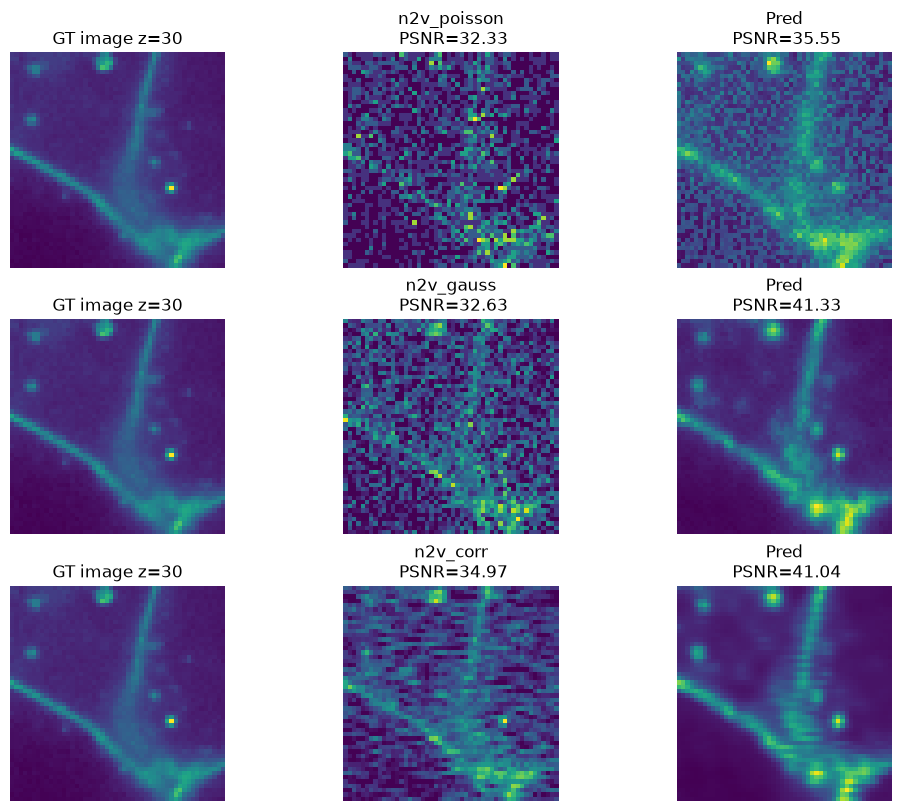

In [185]:
if all_preds and all_noisy:
    # Check results qualitatively
    fig, axes = plt.subplots(len(all_preds.keys()), 3, figsize=(10, 8), constrained_layout=True)

    for i, (exp_name, pred) in enumerate(all_preds.items()):
        axes[i, 0].imshow(img[z_mid, *crop])
        axes[i, 0].set_title(f"GT image z={z_mid}")
        axes[i, 0].axis("off")

        # noisy data
        if exp_name in all_noisy:
            noisy = all_noisy[exp_name]
            noi_psnr = scale_invariant_psnr(img, noisy)
            
            axes[i, 1].imshow(noisy[z_mid, *crop])
            axes[i, 1].set_title(f"{exp_name}\n PSNR={noi_psnr:.2f}")
            axes[i, 1].axis("off")

        # prediction
        pred_psnr = scale_invariant_psnr(img, pred)
        
        axes[i, 2].imshow(pred[z_mid, *crop])
        axes[i, 2].set_title(f"Pred\n PSNR={pred_psnr:.2f}")
        axes[i, 2].axis("off")
else:
    print("`all_preds` is empty, run the notebook prediction step first.")

## Frequently asked questions

<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  Can you apply a trained Noise2Void model to new data?

  <details>
    <summary>
      <strong>Answer</strong>
    </summary>
    Potentially, but only if you are sure that all parameters of the sample and acquisition
    are similar. Noise2Void learns strong structural and noise priors, which may only be
    specific to data acquired in the same circumstances.

    But Noise2Void is fairly quick to train on new data!
</div>

## References

- [CAREamics documentation](https://careamics.github.io/latest/)
- [Noise2Void paper](https://ieeexplore.ieee.org/abstract/document/8954066)
- [N2V2 paper](https://arxiv.org/abs/2211.08512): Noise2Void without cherckerboard artefacts
- [structN2V paper](https://ieeexplore.ieee.org/abstract/document/9098336): Noise2Void against simple correlated noise
- [HDN paper](https://arxiv.org/abs/2104.01374): variational auto-encoder for correslated noise
- [COSDD paper](https://ieeexplore.ieee.org/abstract/document/10944143): variational auto-encoder for correslated noise